In [1]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

In [2]:


df = pd.read_csv("train_data.csv",encoding="latin1")


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

df.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",18-06-2016,t,t,NaN,26-03-2012,f,18-07-2016,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,05-08-2017,t,f,100%,19-06-2017,t,23-09-2017,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,30-04-2017,t,t,100%,25-10-2016,t,14-09-2017,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,NaN,t,t,NaN,19-04-2015,f,NaN,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",12-05-2015,t,t,100%,01-03-2015,t,22-01-2017,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [4]:

df.shape

(74111, 29)

In [5]:
numeric_cols = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'number_of_reviews', 'review_scores_rating',
    'latitude', 'longitude'
]

categorical_cols = [
    'room_type', 'property_type', 'bed_type',
    'cancellation_policy', 'city', 'cleaning_fee',
    'instant_bookable', 'host_has_profile_pic',
    'host_identity_verified'
]

target_col = 'log_price'


In [6]:

if 'amenities' in df.columns:
    amenities_str = df['amenities'].fillna('').astype(str).str.lower()

    df['has_wifi']          = amenities_str.str.contains('wireless internet|wifi').astype(int)
    df['has_ac']            = amenities_str.str.contains('air conditioning').astype(int)
    df['has_kitchen']       = amenities_str.str.contains('kitchen').astype(int)
    df['has_tv']            = amenities_str.str.contains('"tv"').astype(int)
    df['has_washer']        = amenities_str.str.contains('washer').astype(int)
    df['has_dryer']         = amenities_str.str.contains('dryer').astype(int)
    df['has_parking']       = amenities_str.str.contains('parking').astype(int)
    df['has_gym']           = amenities_str.str.contains('gym').astype(int)
    df['has_pool']          = amenities_str.str.contains('pool').astype(int)
    df['has_elevator']      = amenities_str.str.contains('elevator').astype(int)
    df['has_doorman']       = amenities_str.str.contains('doorman').astype(int)
    df['has_breakfast']     = amenities_str.str.contains('breakfast').astype(int)
    df['has_pets']          = amenities_str.str.contains('pets allowed').astype(int)
    df['has_hottub']        = amenities_str.str.contains('hot tub').astype(int)
    # Total amenities count (luxury indicator)
    df['amenity_count']     = amenities_str.str.count(',') + 1
    df['amenity_count']     = df['amenity_count'].clip(0, 50)
    df['log_amenity_count'] = np.log1p(df['amenity_count'])
    print(f'Amenities features extracted: {df[[c for c in df.columns if c.startswith("has_")]].sum().to_dict()}')
else:
    print('amenities column not found — skipping')

if 'neighbourhood' in df.columns:
    df['neighbourhood'] = df['neighbourhood'].fillna('Unknown')
    from sklearn.preprocessing import LabelEncoder
    le_nb = LabelEncoder()
    df['neighbourhood_enc'] = le_nb.fit_transform(df['neighbourhood'].astype(str))
    nb_mean = df.groupby('neighbourhood')['log_price'].mean()
    df['neighbourhood_mean_price'] = df['neighbourhood'].map(nb_mean)
    print('Neighbourhood encoded')

if 'zipcode' in df.columns:
    df['zipcode_num'] = pd.to_numeric(df['zipcode'], errors='coerce').fillna(0).astype(int)
    print(' Zipcode extracted')


extra_numeric = [c for c in [
    'has_wifi','has_ac','has_kitchen','has_tv','has_washer',
    'has_dryer','has_parking','has_gym','has_pool','has_elevator',
    'has_doorman','has_breakfast','has_pets','has_hottub',
    'amenity_count','log_amenity_count',
    'neighbourhood_enc','neighbourhood_mean_price',
    'zipcode_num'
] if c in df.columns]

all_numeric = numeric_cols + extra_numeric
keep_cols   = all_numeric + categorical_cols + [target_col]
keep_cols   = [c for c in keep_cols if c in df.columns]
df          = df[keep_cols].copy()

print(f'\nFinal columns ({len(df.columns)}): {df.columns.tolist()}')
df.head(3)


Amenities features extracted: {'has_wifi': 71271, 'has_ac': 55210, 'has_kitchen': 67526, 'has_tv': 0, 'has_washer': 43791, 'has_dryer': 59045, 'has_parking': 23721, 'has_gym': 7491, 'has_pool': 6283, 'has_elevator': 17237, 'has_doorman': 4670, 'has_breakfast': 8306, 'has_pets': 10197, 'has_hottub': 6330}
Neighbourhood encoded
 Zipcode extracted

Final columns (37): ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'latitude', 'longitude', 'has_wifi', 'has_ac', 'has_kitchen', 'has_tv', 'has_washer', 'has_dryer', 'has_parking', 'has_gym', 'has_pool', 'has_elevator', 'has_doorman', 'has_breakfast', 'has_pets', 'has_hottub', 'amenity_count', 'log_amenity_count', 'neighbourhood_enc', 'neighbourhood_mean_price', 'zipcode_num', 'room_type', 'property_type', 'bed_type', 'cancellation_policy', 'city', 'cleaning_fee', 'instant_bookable', 'host_has_profile_pic', 'host_identity_verified', 'log_price']


,accommodates,bathrooms,bedrooms,beds,number_of_reviews,review_scores_rating,latitude,longitude,has_wifi,has_ac,has_kitchen,has_tv,has_washer,has_dryer,has_parking,has_gym,has_pool,has_elevator,has_doorman,has_breakfast,has_pets,has_hottub,amenity_count,log_amenity_count,neighbourhood_enc,neighbourhood_mean_price,zipcode_num,room_type,property_type,bed_type,cancellation_policy,city,cleaning_fee,instant_bookable,host_has_profile_pic,host_identity_verified,log_price
0,3,1.0,1.0,1.0,2,100.0,40.696524,-73.991617,1,1,1,0,0,1,0,0,0,0,0,0,0,0,9,2.302585,77,5.013296,11201,Entire home/apt,Apartment,Real Bed,strict,NYC,True,f,t,t,5.010635
1,7,1.0,3.0,3.0,6,93.0,40.766115,-73.989040,1,1,1,0,1,1,0,0,0,0,0,0,0,0,15,2.772589,252,5.131274,10019,Entire home/apt,Apartment,Real Bed,strict,NYC,True,t,t,f,5.129899
2,5,1.0,1.0,3.0,10,92.0,40.808110,-73.943756,1,1,1,0,0,1,0,0,0,0,0,1,0,0,19,2.995732,247,4.636397,10027,Entire home/apt,Apartment,Real Bed,moderate,NYC,True,t,t,t,4.976734


In [7]:
df.shape
df.columns

Index(['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews',
       'review_scores_rating', 'latitude', 'longitude', 'has_wifi', 'has_ac',
       'has_kitchen', 'has_tv', 'has_washer', 'has_dryer', 'has_parking',
       'has_gym', 'has_pool', 'has_elevator', 'has_doorman', 'has_breakfast',
       'has_pets', 'has_hottub', 'amenity_count', 'log_amenity_count',
       'neighbourhood_enc', 'neighbourhood_mean_price', 'zipcode_num',
       'room_type', 'property_type', 'bed_type', 'cancellation_policy', 'city',
       'cleaning_fee', 'instant_bookable', 'host_has_profile_pic',
       'host_identity_verified', 'log_price'],
      dtype='str')

In [8]:
df.isnull().sum()

accommodates                    0
bathrooms                     200
bedrooms                       91
beds                          131
number_of_reviews               0
review_scores_rating        16722
latitude                        0
longitude                       0
has_wifi                        0
has_ac                          0
has_kitchen                     0
has_tv                          0
has_washer                      0
has_dryer                       0
has_parking                     0
has_gym                         0
has_pool                        0
has_elevator                    0
has_doorman                     0
has_breakfast                   0
has_pets                        0
has_hottub                      0
amenity_count                   0
log_amenity_count               0
neighbourhood_enc               0
neighbourhood_mean_price        0
zipcode_num                     0
room_type                       0
property_type                   0
bed_type      

In [9]:
num_fill_cols = ["bathrooms", "bedrooms", "beds", "review_scores_rating"]

for col in num_fill_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [10]:
cat_fill_cols = ["host_has_profile_pic", "host_identity_verified"]

for col in cat_fill_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [11]:


df['beds_per_person']   = df['beds']      / df['accommodates'].clip(1)
df['bath_per_person']   = df['bathrooms'] / df['accommodates'].clip(1)
df['bed_bath_ratio']    = df['beds']      / (df['bathrooms'] + 0.5)
df['room_per_person']   = df['bedrooms']  / df['accommodates'].clip(1)
df['price_per_person']  = df['accommodates'] / (df['bedrooms'] + 1)
df['beds_per_bedroom']  = df['beds'] / (df['bedrooms'] + 0.5)


df['log_reviews']       = np.log1p(df['number_of_reviews'])
df['log_accommodates']  = np.log1p(df['accommodates'])
df['sqrt_accommodates'] = np.sqrt(df['accommodates'])


df['high_rating']       = (df['review_scores_rating'] >= 95).astype(int)
df['low_rating']        = (df['review_scores_rating'] < 80).astype(int)
df['perfect_rating']    = (df['review_scores_rating'] == 100).astype(int)
df['new_listing']       = (df['number_of_reviews'] == 0).astype(int)
df['popular_listing']   = (df['number_of_reviews'] > 20).astype(int)


df['lat_lon_interact']  = df['latitude'] * df['longitude']
df['lat_rounded']       = (df['latitude']  * 10).round() / 10
df['lon_rounded']       = (df['longitude'] * 10).round() / 10


city_mean = df.groupby('city')['log_price'].mean()
city_med  = df.groupby('city')['log_price'].median()
city_std  = df.groupby('city')['log_price'].std()
df['city_mean_price']   = df['city'].map(city_mean)
df['city_median_price'] = df['city'].map(city_med)
df['city_std_price']    = df['city'].map(city_std)

room_mean = df.groupby('room_type')['log_price'].mean()
room_std  = df.groupby('room_type')['log_price'].std()
df['room_mean_price']   = df['room_type'].map(room_mean)
df['room_std_price']    = df['room_type'].map(room_std)

prop_mean = df.groupby('property_type')['log_price'].mean()
df['prop_mean_price']   = df['property_type'].map(prop_mean)


if 'neighbourhood_enc' in df.columns:
    nb_grp = df.groupby('neighbourhood_enc')['log_price']
    df['neighbourhood_mean_price'] = df['neighbourhood_enc'].map(nb_grp.mean())
    df['neighbourhood_std_price']  = df['neighbourhood_enc'].map(nb_grp.std().fillna(0))


if 'amenity_count' in df.columns:
    df['luxury_score'] = (
        df.get('has_pool', 0) * 3 +
        df.get('has_gym', 0) * 2 +
        df.get('has_doorman', 0) * 2 +
        df.get('has_hottub', 0) * 2 +
        df.get('has_elevator', 0) * 1 +
        df.get('has_parking', 0) * 1
    )


q_lo = df['log_price'].quantile(0.01)
q_hi = df['log_price'].quantile(0.99)
df   = df[(df['log_price'] >= q_lo) & (df['log_price'] <= q_hi)].copy()

print(f'Feature engineering done!')
print(f'   Rows : {len(df)}')
print(f'   Cols : {len(df.columns)}')


Feature engineering done!
   Rows : 72651
   Cols : 62


In [12]:
df.isnull().sum()

accommodates                    0
bathrooms                     199
bedrooms                       90
beds                          130
number_of_reviews               0
review_scores_rating        16036
latitude                        0
longitude                       0
has_wifi                        0
has_ac                          0
has_kitchen                     0
has_tv                          0
has_washer                      0
has_dryer                       0
has_parking                     0
has_gym                         0
has_pool                        0
has_elevator                    0
has_doorman                     0
has_breakfast                   0
has_pets                        0
has_hottub                      0
amenity_count                   0
log_amenity_count               0
neighbourhood_enc               0
neighbourhood_mean_price        0
zipcode_num                     0
room_type                       0
property_type                   0
bed_type      

In [13]:
from sklearn.preprocessing import LabelEncoder


label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {list(le.classes_)[:4]}' + ('...' if len(le.classes_)>4 else ''))

df['city_x_room']   = df['city']      * df['room_type']
df['room_x_accom']  = df['room_type'] * df['accommodates']
df['city_x_accom']  = df['city']      * df['accommodates']
df['city_x_prop']   = df['city']      * df['property_type']

print(f'\nEncoding + interactions done!')
print(f'   Total features: {len(df.columns)-1}')


  room_type: ['Entire home/apt', 'Private room', 'Shared room']
  property_type: ['Apartment', 'Bed & Breakfast', 'Boat', 'Boutique hotel']...
  bed_type: ['Airbed', 'Couch', 'Futon', 'Pull-out Sofa']...
  cancellation_policy: ['flexible', 'moderate', 'strict', 'super_strict_30']...
  city: ['Boston', 'Chicago', 'DC', 'LA']...
  cleaning_fee: ['False', 'True']
  instant_bookable: ['f', 't']
  host_has_profile_pic: ['f', 't', nan]
  host_identity_verified: ['f', 't', nan]

Encoding + interactions done!
   Total features: 65


In [14]:
df.head()

,accommodates,bathrooms,bedrooms,beds,number_of_reviews,review_scores_rating,latitude,longitude,has_wifi,has_ac,has_kitchen,has_tv,has_washer,has_dryer,has_parking,has_gym,has_pool,has_elevator,has_doorman,has_breakfast,has_pets,has_hottub,amenity_count,log_amenity_count,neighbourhood_enc,neighbourhood_mean_price,zipcode_num,room_type,property_type,bed_type,cancellation_policy,city,cleaning_fee,instant_bookable,host_has_profile_pic,host_identity_verified,log_price,beds_per_person,bath_per_person,bed_bath_ratio,room_per_person,price_per_person,beds_per_bedroom,log_reviews,log_accommodates,sqrt_accommodates,high_rating,low_rating,perfect_rating,new_listing,popular_listing,lat_lon_interact,lat_rounded,lon_rounded,city_mean_price,city_median_price,city_std_price,room_mean_price,room_std_price,prop_mean_price,neighbourhood_std_price,luxury_score,city_x_room,room_x_accom,city_x_accom,city_x_prop
0,3,1.0,1.0,1.0,2,100.0,40.696524,-73.991617,1,1,1,0,0,1,0,0,0,0,0,0,0,0,9,2.302585,77,5.013296,11201,0,0,4,2,4,1,0,1,1,5.010635,0.333333,0.333333,0.666667,0.333333,1.500000,0.666667,1.098612,1.386294,1.732051,1,0,1,0,0,-3011.201584,40.7,-74.0,4.719340,4.653960,0.661567,5.167217,0.609443,4.758850,0.498101,0,0,0,12,0
1,7,1.0,3.0,3.0,6,93.0,40.766115,-73.989040,1,1,1,0,1,1,0,0,0,0,0,0,0,0,15,2.772589,252,5.131274,10019,0,0,4,2,4,1,1,1,0,5.129899,0.428571,0.142857,2.000000,0.428571,1.750000,0.857143,1.945910,2.079442,2.645751,0,0,0,0,0,-3016.245741,40.8,-74.0,4.719340,4.653960,0.661567,5.167217,0.609443,4.758850,0.578707,0,0,0,28,0
2,5,1.0,1.0,3.0,10,92.0,40.808110,-73.943756,1,1,1,0,0,1,0,0,0,0,0,1,0,0,19,2.995732,247,4.636397,10027,0,0,4,1,4,1,1,1,1,4.976734,0.600000,0.200000,2.000000,0.200000,2.500000,2.000000,2.397895,1.791759,2.236068,0,0,0,0,0,-3017.504921,40.8,-73.9,4.719340,4.653960,0.661567,5.167217,0.609443,4.758850,0.565244,0,0,0,20,0
3,4,1.0,2.0,2.0,0,NaN,37.772004,-122.431619,1,0,1,0,1,1,0,0,0,0,0,0,0,0,15,2.772589,325,5.263010,94117,0,17,4,0,5,1,0,1,1,6.620073,0.500000,0.250000,1.333333,0.500000,1.333333,0.800000,0.000000,1.609438,2.000000,0,0,0,1,0,-4624.487650,37.8,-122.4,5.170014,5.105945,0.679514,5.167217,0.609443,4.797114,0.653562,0,0,0,20,85
4,2,1.0,0.0,1.0,4,40.0,38.925627,-77.034596,1,1,1,0,0,0,0,0,0,1,0,0,0,0,12,2.564949,119,4.887983,20009,0,0,4,1,2,1,1,1,1,4.744932,0.500000,0.500000,0.666667,0.000000,2.000000,2.000000,1.609438,1.098612,1.414214,0,1,0,0,0,-2998.619925,38.9,-77.0,4.986798,4.828314,0.821160,5.167217,0.609443,4.758850,0.780001,1,0,0,4,0


In [15]:
X = df.drop('log_price', axis=1)
y = df['log_price']

print(f'Features: {X.shape[1]}')
print(f'Samples : {X.shape[0]}')
print(f'Feature list: {X.columns.tolist()}')

Features: 65
Samples : 72651
Feature list: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'latitude', 'longitude', 'has_wifi', 'has_ac', 'has_kitchen', 'has_tv', 'has_washer', 'has_dryer', 'has_parking', 'has_gym', 'has_pool', 'has_elevator', 'has_doorman', 'has_breakfast', 'has_pets', 'has_hottub', 'amenity_count', 'log_amenity_count', 'neighbourhood_enc', 'neighbourhood_mean_price', 'zipcode_num', 'room_type', 'property_type', 'bed_type', 'cancellation_policy', 'city', 'cleaning_fee', 'instant_bookable', 'host_has_profile_pic', 'host_identity_verified', 'beds_per_person', 'bath_per_person', 'bed_bath_ratio', 'room_per_person', 'price_per_person', 'beds_per_bedroom', 'log_reviews', 'log_accommodates', 'sqrt_accommodates', 'high_rating', 'low_rating', 'perfect_rating', 'new_listing', 'popular_listing', 'lat_lon_interact', 'lat_rounded', 'lon_rounded', 'city_mean_price', 'city_median_price', 'city_std_price', 'room_mean_price', 'room_std_p

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train = scaler.fit_transform(X_train)   # fit on train
# X_test = scaler.transform(X_test)         # only transform test

In [18]:

X_train.shape, X_test.shape

((58120, 65), (14531, 65))

In [19]:
!pip install xgboost

In [20]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Quick baseline model
temp_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
temp_model.fit(X_train, y_train)

baseline_pred = temp_model.predict(X_test)
baseline_r2   = r2_score(y_test, baseline_pred)
print(f'Baseline R²: {baseline_r2:.4f}')

Baseline R²: 0.7146


In [21]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': temp_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(f'Total features: {len(importance)}')
print(importance.to_string())


Total features: 65
                     feature  importance
27                 room_type    0.685913
1                  bathrooms    0.064845
25  neighbourhood_mean_price    0.037506
2                   bedrooms    0.036664
63              city_x_accom    0.020656
55            city_std_price    0.014810
54         city_median_price    0.009747
53           city_mean_price    0.008565
0               accommodates    0.007854
17              has_elevator    0.006189
15                   has_gym    0.005207
26               zipcode_num    0.004320
40          price_per_person    0.004150
58           prop_mean_price    0.003960
60              luxury_score    0.003853
61               city_x_room    0.003661
31                      city    0.003594
12                has_washer    0.003589
4          number_of_reviews    0.003416
9                     has_ac    0.003086
32              cleaning_fee    0.003078
37           bath_per_person    0.003046
5       review_scores_rating    0.0029

In [22]:
importance

,feature,importance
27,room_type,0.685913
1,bathrooms,0.064845
25,neighbourhood_mean_price,0.037506
2,bedrooms,0.036664
63,city_x_accom,0.020656
55,city_std_price,0.014810
54,city_median_price,0.009747
53,city_mean_price,0.008565
0,accommodates,0.007854
17,has_elevator,0.006189


In [23]:
importance.head(10)

,feature,importance
27,room_type,0.685913
1,bathrooms,0.064845
25,neighbourhood_mean_price,0.037506
2,bedrooms,0.036664
63,city_x_accom,0.020656
55,city_std_price,0.014810
54,city_median_price,0.009747
53,city_mean_price,0.008565
0,accommodates,0.007854
17,has_elevator,0.006189


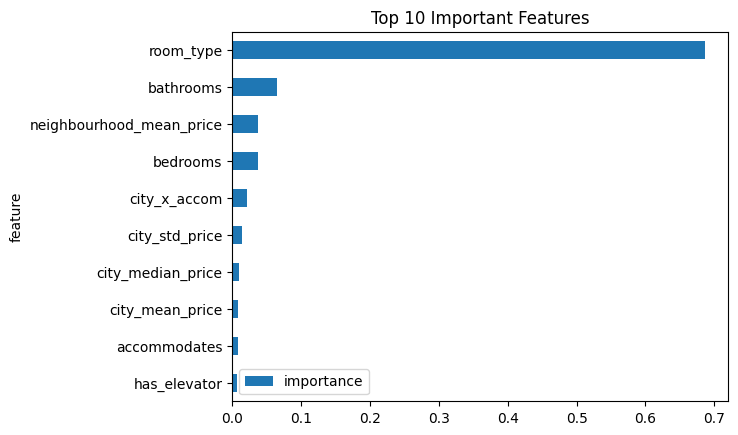

In [24]:
import matplotlib.pyplot as plt

importance.head(10).plot(
    x="feature", y="importance", kind="barh"
)
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [25]:

selected_features = X_train.columns.tolist()
print(f'✅ Using ALL {len(selected_features)} features')
print(f'Features: {selected_features}')

X_train_sel = X_train
X_test_sel  = X_test


✅ Using ALL 65 features
Features: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'latitude', 'longitude', 'has_wifi', 'has_ac', 'has_kitchen', 'has_tv', 'has_washer', 'has_dryer', 'has_parking', 'has_gym', 'has_pool', 'has_elevator', 'has_doorman', 'has_breakfast', 'has_pets', 'has_hottub', 'amenity_count', 'log_amenity_count', 'neighbourhood_enc', 'neighbourhood_mean_price', 'zipcode_num', 'room_type', 'property_type', 'bed_type', 'cancellation_policy', 'city', 'cleaning_fee', 'instant_bookable', 'host_has_profile_pic', 'host_identity_verified', 'beds_per_person', 'bath_per_person', 'bed_bath_ratio', 'room_per_person', 'price_per_person', 'beds_per_bedroom', 'log_reviews', 'log_accommodates', 'sqrt_accommodates', 'high_rating', 'low_rating', 'perfect_rating', 'new_listing', 'popular_listing', 'lat_lon_interact', 'lat_rounded', 'lon_rounded', 'city_mean_price', 'city_median_price', 'city_std_price', 'room_mean_price', 'room_std_price', 'p

In [26]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

xgb_model = XGBRegressor(random_state=42)

xgb_model.fit(X_train_sel, y_train)

y_pred_xgb = xgb_model.predict(X_test_sel)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(" XGBoost (Before Tuning)")
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

 XGBoost (Before Tuning)
RMSE: 0.3588143951539487
R2: 0.7076830433466217


In [27]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

best_model = XGBRegressor(
    n_estimators          = 3000,
    max_depth             = 9,
    learning_rate         = 0.01,
    subsample             = 0.8,
    colsample_bytree      = 0.7,
    colsample_bylevel     = 0.7,
    colsample_bynode      = 0.7,
    min_child_weight      = 3,
    gamma                 = 0.0,
    reg_alpha             = 0.05,
    reg_lambda            = 1.0,
    random_state          = 42,
    n_jobs                = -1,
    eval_metric           = 'rmse',
    early_stopping_rounds = 150,
)


best_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=300
)

y_pred     = best_model.predict(X_test)
r2_final   = r2_score(y_test, y_pred)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred))
mae_final  = np.mean(np.abs(np.exp(y_pred) - np.exp(y_test)))

w10 = np.mean(np.abs(np.exp(y_pred) - np.exp(y_test)) / np.exp(y_test) < 0.10) * 100
w20 = np.mean(np.abs(np.exp(y_pred) - np.exp(y_test)) / np.exp(y_test) < 0.20) * 100

print('='*52)
print('FINAL MODEL RESULTS')
print('='*52)
print(f'R²            : {r2_final:.4f}  ({r2_final*100:.1f}%)')
print(f'RMSE          : {rmse_final:.4f}')
print(f'MAE (real $)  : ${mae_final:.2f}')
print(f'Within ±10%   : {w10:.1f}%')
print(f'Within ±20%   : {w20:.1f}%')
print(f'Best iteration: {best_model.best_iteration}')
print(f'Features used : {len(X_train.columns)}')
if r2_final >= 0.80:   grade = 'Excellent'
elif r2_final >= 0.75: grade = 'Very Good'
elif r2_final >= 0.70: grade = 'Good'
else:                  grade = 'Fair'
print(f'Grade         : {grade}')
print('='*52)


[0]	validation_0-rmse:4.28364	validation_1-rmse:4.28206
[300]	validation_0-rmse:0.39939	validation_1-rmse:0.42224
[600]	validation_0-rmse:0.30957	validation_1-rmse:0.35421
[900]	validation_0-rmse:0.29441	validation_1-rmse:0.35118
[1200]	validation_0-rmse:0.28247	validation_1-rmse:0.34967
[1500]	validation_0-rmse:0.27134	validation_1-rmse:0.34869
[1800]	validation_0-rmse:0.26090	validation_1-rmse:0.34806
[2100]	validation_0-rmse:0.25126	validation_1-rmse:0.34763
[2400]	validation_0-rmse:0.24244	validation_1-rmse:0.34733
[2700]	validation_0-rmse:0.23364	validation_1-rmse:0.34703
[2999]	validation_0-rmse:0.22533	validation_1-rmse:0.34696
FINAL MODEL RESULTS
R²            : 0.7267  (72.7%)
RMSE          : 0.3469
MAE (real $)  : $40.72
Within ±10%   : 27.0%
Within ±20%   : 50.7%
Best iteration: 2973
Features used : 65
Grade         : Good


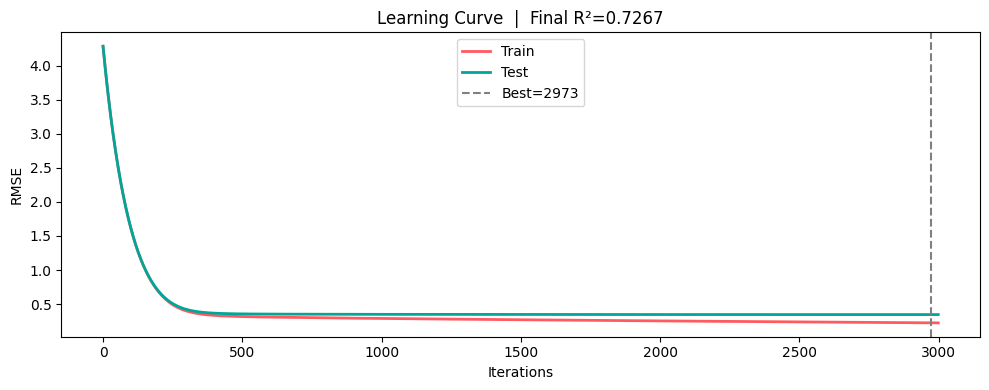

Learning curve shown


In [28]:

results = best_model.evals_result()
plt.figure(figsize=(10, 4))
plt.plot(results['validation_0']['rmse'], label='Train', color='#FF5A5F', lw=2)
plt.plot(results['validation_1']['rmse'], label='Test',  color='#00A699', lw=2)
plt.axvline(x=best_model.best_iteration, color='gray', linestyle='--', label=f'Best={best_model.best_iteration}')
plt.xlabel('Iterations'); plt.ylabel('RMSE')
plt.title(f'Learning Curve  |  Final R²={r2_final:.4f}')
plt.legend(); plt.tight_layout(); plt.show()
print('Learning curve shown')

In [29]:

y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)

print(f'Sample predictions (real $):')
print(y_pred_actual[:10].round(2))
print(f'\nSample actual (real $):')
print(y_test_actual[:10].round(2))


Sample predictions (real $):
[170.19  93.72  59.38 177.81  61.01 124.41 143.   132.89 266.14 178.47]

Sample actual (real $):
61200     94.0
16709    120.0
40143     56.0
42574    120.0
35886     70.0
42415    115.0
51856    155.0
21783    155.0
12761    300.0
72760    170.0
Name: log_price, dtype: float64


In [30]:
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)

In [31]:
np.exp(df["log_price"]).head()

0    150.0
1    169.0
2    145.0
3    750.0
4    115.0
Name: log_price, dtype: float64

In [32]:
df.head()

,accommodates,bathrooms,bedrooms,beds,number_of_reviews,review_scores_rating,latitude,longitude,has_wifi,has_ac,has_kitchen,has_tv,has_washer,has_dryer,has_parking,has_gym,has_pool,has_elevator,has_doorman,has_breakfast,has_pets,has_hottub,amenity_count,log_amenity_count,neighbourhood_enc,neighbourhood_mean_price,zipcode_num,room_type,property_type,bed_type,cancellation_policy,city,cleaning_fee,instant_bookable,host_has_profile_pic,host_identity_verified,log_price,beds_per_person,bath_per_person,bed_bath_ratio,room_per_person,price_per_person,beds_per_bedroom,log_reviews,log_accommodates,sqrt_accommodates,high_rating,low_rating,perfect_rating,new_listing,popular_listing,lat_lon_interact,lat_rounded,lon_rounded,city_mean_price,city_median_price,city_std_price,room_mean_price,room_std_price,prop_mean_price,neighbourhood_std_price,luxury_score,city_x_room,room_x_accom,city_x_accom,city_x_prop
0,3,1.0,1.0,1.0,2,100.0,40.696524,-73.991617,1,1,1,0,0,1,0,0,0,0,0,0,0,0,9,2.302585,77,5.013296,11201,0,0,4,2,4,1,0,1,1,5.010635,0.333333,0.333333,0.666667,0.333333,1.500000,0.666667,1.098612,1.386294,1.732051,1,0,1,0,0,-3011.201584,40.7,-74.0,4.719340,4.653960,0.661567,5.167217,0.609443,4.758850,0.498101,0,0,0,12,0
1,7,1.0,3.0,3.0,6,93.0,40.766115,-73.989040,1,1,1,0,1,1,0,0,0,0,0,0,0,0,15,2.772589,252,5.131274,10019,0,0,4,2,4,1,1,1,0,5.129899,0.428571,0.142857,2.000000,0.428571,1.750000,0.857143,1.945910,2.079442,2.645751,0,0,0,0,0,-3016.245741,40.8,-74.0,4.719340,4.653960,0.661567,5.167217,0.609443,4.758850,0.578707,0,0,0,28,0
2,5,1.0,1.0,3.0,10,92.0,40.808110,-73.943756,1,1,1,0,0,1,0,0,0,0,0,1,0,0,19,2.995732,247,4.636397,10027,0,0,4,1,4,1,1,1,1,4.976734,0.600000,0.200000,2.000000,0.200000,2.500000,2.000000,2.397895,1.791759,2.236068,0,0,0,0,0,-3017.504921,40.8,-73.9,4.719340,4.653960,0.661567,5.167217,0.609443,4.758850,0.565244,0,0,0,20,0
3,4,1.0,2.0,2.0,0,NaN,37.772004,-122.431619,1,0,1,0,1,1,0,0,0,0,0,0,0,0,15,2.772589,325,5.263010,94117,0,17,4,0,5,1,0,1,1,6.620073,0.500000,0.250000,1.333333,0.500000,1.333333,0.800000,0.000000,1.609438,2.000000,0,0,0,1,0,-4624.487650,37.8,-122.4,5.170014,5.105945,0.679514,5.167217,0.609443,4.797114,0.653562,0,0,0,20,85
4,2,1.0,0.0,1.0,4,40.0,38.925627,-77.034596,1,1,1,0,0,0,0,0,0,1,0,0,0,0,12,2.564949,119,4.887983,20009,0,0,4,1,2,1,1,1,1,4.744932,0.500000,0.500000,0.666667,0.000000,2.000000,2.000000,1.609438,1.098612,1.414214,0,1,0,0,0,-2998.619925,38.9,-77.0,4.986798,4.828314,0.821160,5.167217,0.609443,4.758850,0.780001,1,0,0,4,0


In [33]:

y_pred_actual = np.exp(y_pred)
print('Sample predictions ($):',  y_pred_actual[:5].round(2))


Sample predictions ($): [170.19  93.72  59.38 177.81  61.01]


In [34]:
import pandas as pd
baseline_pred_full = temp_model.predict(X_test)  
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_pred_full))

results = {
    'Model': ['Baseline XGB', 'Optimized XGB'],
    'R2':    [round(baseline_r2, 4),    round(r2_final, 4)],
    'RMSE':  [round(rmse_baseline, 4),  round(rmse_final, 4)],
}
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


        Model     R2   RMSE
 Baseline XGB 0.7146 0.3546
Optimized XGB 0.7267 0.3469


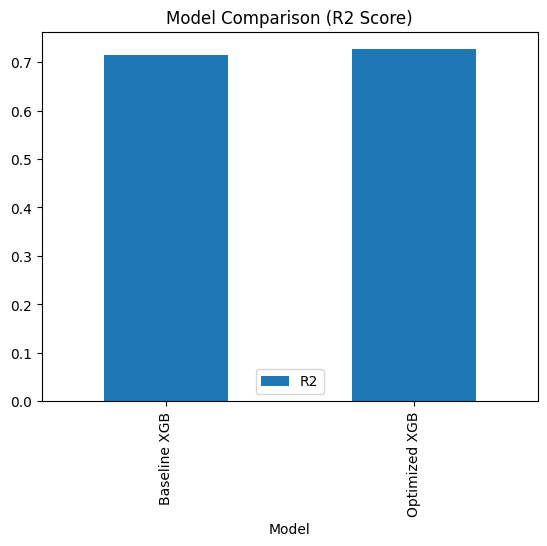

In [35]:
results_df.plot(x="Model", y="R2", kind="bar")
plt.title("Model Comparison (R2 Score)")
plt.show()

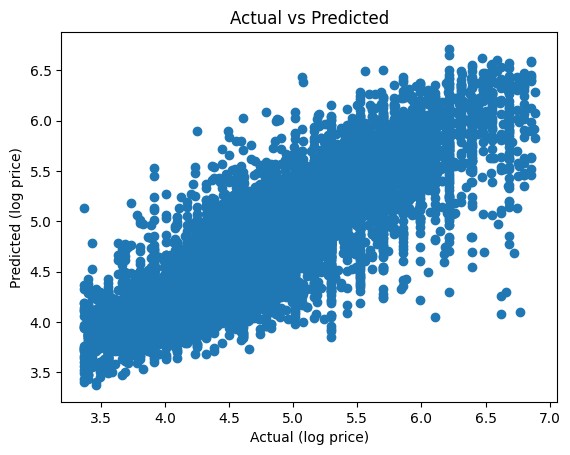

In [36]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual (log price)")
plt.ylabel("Predicted (log price)")
plt.title("Actual vs Predicted")
plt.show()

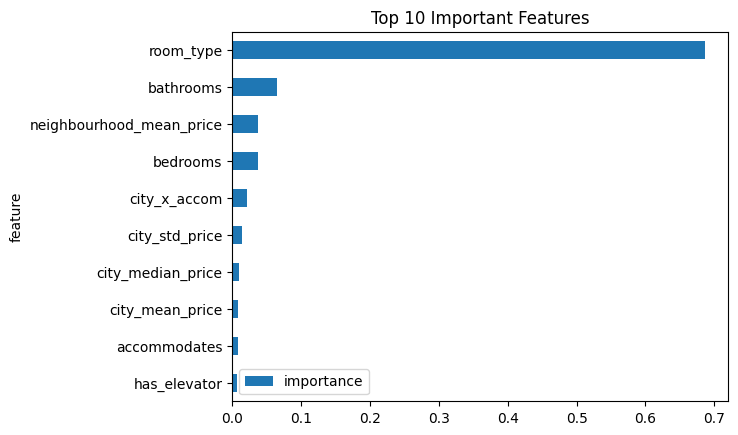

In [37]:
importance.head(10).plot(
    x="feature", y="importance", kind="barh"
)
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

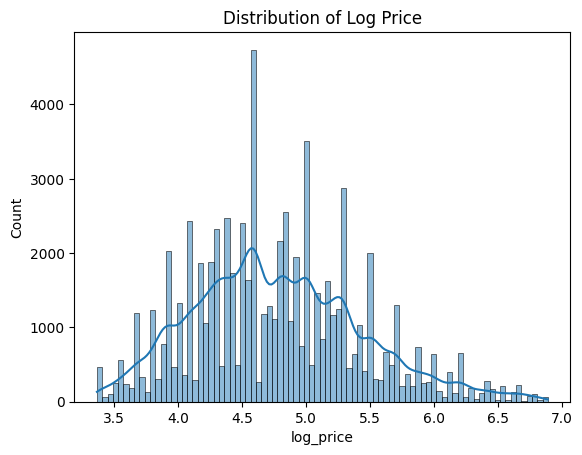

In [38]:
import seaborn as sns

sns.histplot(df["log_price"], kde=True)
plt.title("Distribution of Log Price")
plt.show()

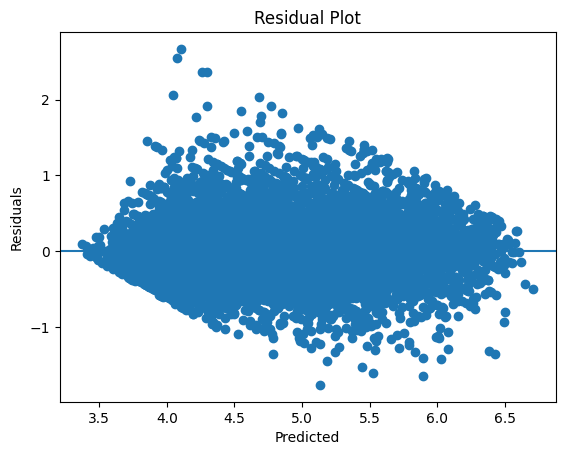

In [39]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

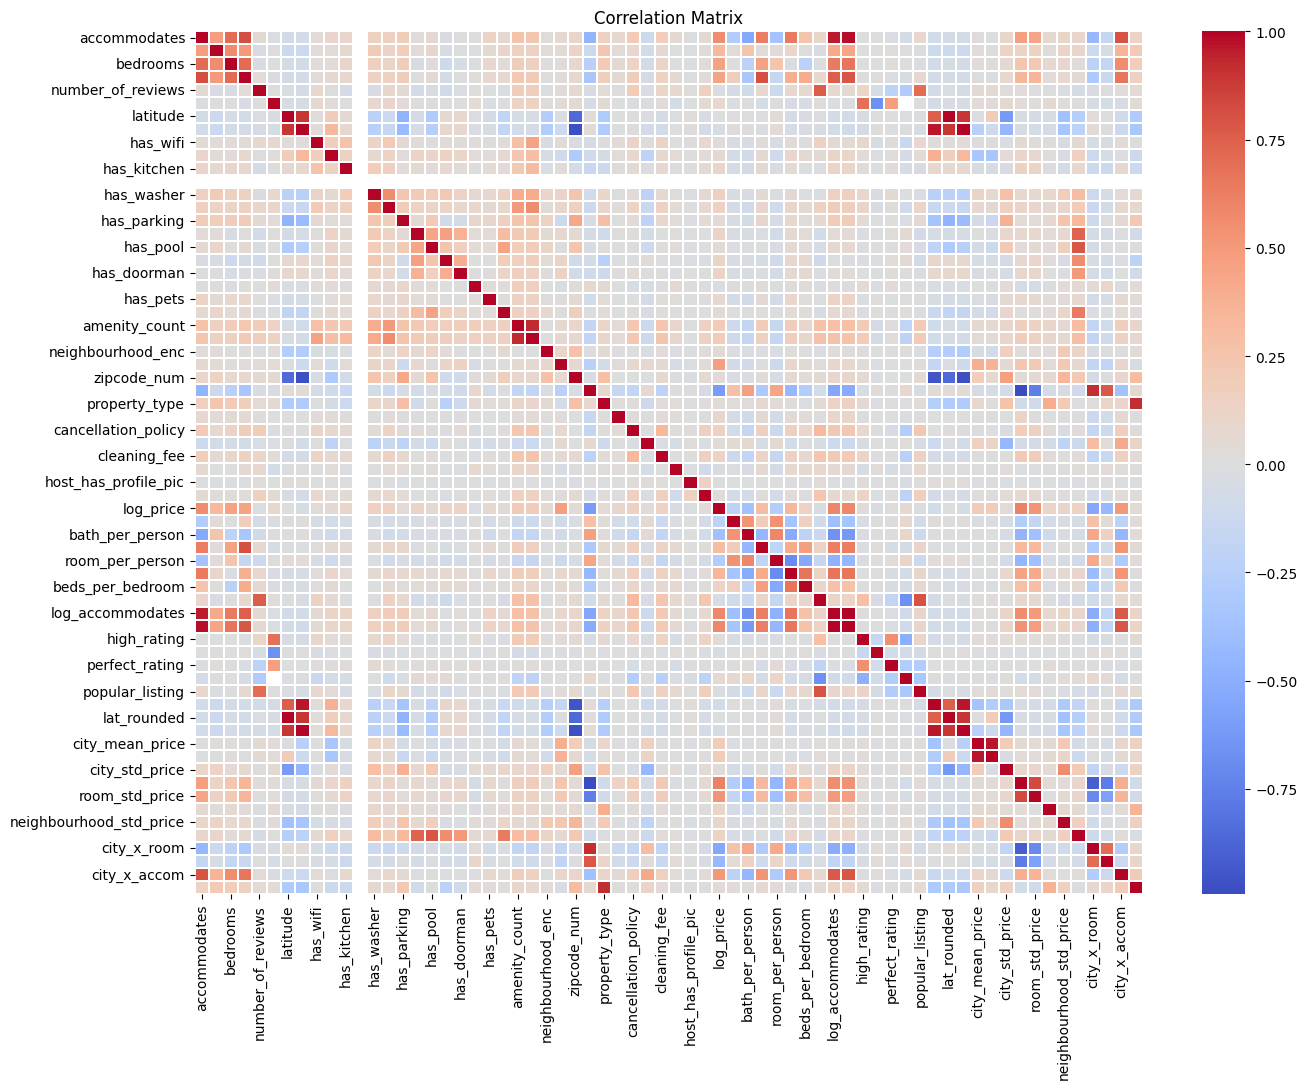

In [40]:
plt.figure(figsize=(14, 11))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.3)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


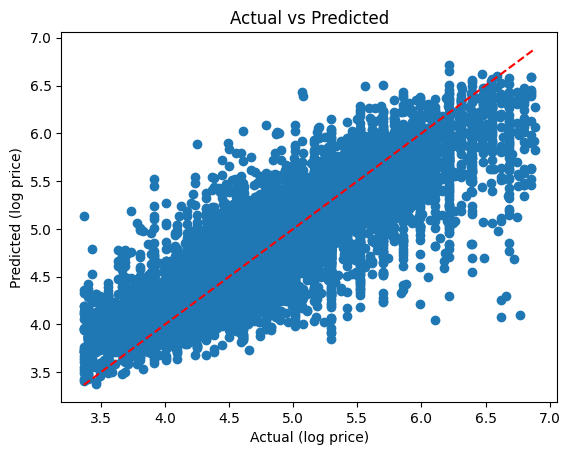

In [41]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

plt.scatter(y_test, y_pred)


min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')  # red dashed line

plt.xlabel("Actual (log price)")
plt.ylabel("Predicted (log price)")
plt.title("Actual vs Predicted")

plt.show()

In [42]:
import joblib, json

joblib.dump(best_model,      'xgb_model.pkl')
joblib.dump(label_encoders,  'label_encoders.pkl')


with open('feature_info.json', 'w') as f:
    json.dump({'features': list(X_train.columns)}, f, indent=2)

with open('model_metrics.json', 'w') as f:
    json.dump({
        'r2':   float(r2_final),
        'rmse': float(rmse_final),
        'mae':  float(mae_final)
    }, f, indent=2)

print(' Saved: xgb_model.pkl, label_encoders.pkl')
print('Saved: feature_info.json, model_metrics.json')
print(f'Final R² = {r2_final:.4f}  ({r2_final*100:.1f}%)')


 Saved: xgb_model.pkl, label_encoders.pkl
Saved: feature_info.json, model_metrics.json
Final R² = 0.7267  (72.7%)


In [43]:
import json

def make_encoded_stats(stat_dict, col):
    result = {}
    if col in label_encoders:
        le = label_encoders[col]
        for name, val in stat_dict.items():
            name_str = str(name)
            if name_str in le.classes_:
                enc_idx = str(le.transform([name_str])[0])
                result[enc_idx] = float(val)
    else:
        for k, v in stat_dict.items():
            result[str(k)] = float(v)
    return result

stats = {
    'city_mean': make_encoded_stats(city_mean, 'city'),
    'city_med' : make_encoded_stats(city_med,  'city'),
    'city_std' : make_encoded_stats(city_std,  'city'),
    'room_mean': make_encoded_stats(room_mean, 'room_type'),
    'room_std' : make_encoded_stats(room_std,  'room_type'),
    'prop_mean': make_encoded_stats(prop_mean, 'property_type'),
}

with open('encoding_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

print('encoding_stats.json saved!')
print(f'   City means  : {stats["city_mean"]}')
print(f'   Room means  : {stats["room_mean"]}')

encoding_stats.json saved!
   City means  : {'0': 4.884035042031142, '1': 4.620079184377521, '2': 4.986798219725738, '3': 4.7204963066599115, '4': 4.719340076585737, '5': 5.170014250462077}
   Room means  : {'0': 5.167216959713968, '1': 4.327752836534239, '2': 3.8615347541026357}


In [44]:

print(f"Final R² = {r2_final:.4f}")

Final R² = 0.7267


In [45]:

import os, joblib

def load_real_data(n=1000):

    if os.path.exists('real_test_data.csv'):
        print('real_test_data.csv mili!')
        d = pd.read_csv('real_test_data.csv', encoding='latin1')
        prices = d['price'].values[:n] if 'price' in d.columns else \
                 np.exp(d['log_price'].values[:n]) if 'log_price' in d.columns else None
        return d.head(n), prices, 'real_test_data.csv'

    
    if os.path.exists('listings.csv.gz') and not os.path.exists('listings.csv'):
        import gzip, shutil
        print('listings.csv.gz extract ho rahi hai...')
        with gzip.open('listings.csv.gz','rb') as fi, open('listings.csv','wb') as fo:
            shutil.copyfileobj(fi, fo)

    if os.path.exists('listings.csv'):
        print('listings.csv mili!')
        raw = pd.read_csv('listings.csv', low_memory=False)
        raw['price'] = raw.get('price', '0').astype(str).str.replace(r'[$,]','',regex=True)
        raw['price'] = pd.to_numeric(raw['price'], errors='coerce')
        raw = raw[raw['price'].between(10, 5000)].copy()
        raw['log_price'] = np.log(raw['price'])
        raw.to_csv('real_test_data.csv', index=False)
        return raw.head(n), raw['price'].values[:n], 'listings.csv'

    orig = pd.read_csv('train_data.csv', encoding='latin1')
    tail = orig.tail(n).copy()
    return tail, np.exp(tail['log_price'].values), 'train_data.csv (last 1000)'


raw_real, actual_prices, source = load_real_data(1000)
print(f'Source : {source}')
print(f'Rows   : {len(raw_real)}')
if actual_prices is not None:
    print(f'Price  : ${actual_prices.min():.0f} – ${actual_prices.max():.0f}'
          f'  |  Median: ${np.median(actual_prices):.0f}')


real_test_data.csv mili!
Source : real_test_data.csv
Rows   : 1000
Price  : $15 – $480  |  Median: $177


In [46]:

import os, joblib

def load_real_data(n=1000):

    if os.path.exists('real_test_data.csv'):
        print('real_test_data.csv mili!')
        d = pd.read_csv('real_test_data.csv', encoding='latin1')
        prices = d['price'].values[:n] if 'price' in d.columns else \
                 np.exp(d['log_price'].values[:n]) if 'log_price' in d.columns else None
        return d.head(n), prices, 'real_test_data.csv'

    
    if os.path.exists('listings.csv.gz') and not os.path.exists('listings.csv'):
        import gzip, shutil
        print('listings.csv.gz extract ho rahi hai...')
        with gzip.open('listings.csv.gz','rb') as fi, open('listings.csv','wb') as fo:
            shutil.copyfileobj(fi, fo)

    if os.path.exists('listings.csv'):
        print('listings.csv mili!')
        raw = pd.read_csv('listings.csv', low_memory=False)
        raw['price'] = raw.get('price', '0').astype(str).str.replace(r'[$,]','',regex=True)
        raw['price'] = pd.to_numeric(raw['price'], errors='coerce')
        raw = raw[raw['price'].between(10, 5000)].copy()
        raw['log_price'] = np.log(raw['price'])
        raw.to_csv('real_test_data.csv', index=False)
        return raw.head(n), raw['price'].values[:n], 'listings.csv'

    orig = pd.read_csv('train_data.csv', encoding='latin1')
    tail = orig.tail(n).copy()
    return tail, np.exp(tail['log_price'].values), 'train_data.csv (last 1000)'


raw_real, actual_prices, source = load_real_data(1000)
print(f'Source : {source}')
print(f'Rows   : {len(raw_real)}')
if actual_prices is not None:
    print(f'Price  : ${actual_prices.min():.0f} – ${actual_prices.max():.0f}'
          f'  |  Median: ${np.median(actual_prices):.0f}')


real_test_data.csv mili!
Source : real_test_data.csv
Rows   : 1000
Price  : $15 – $480  |  Median: $177


In [47]:
# ── Preprocess real data — same steps as training ──────────────

def preprocess_for_model(df_raw, model_features):
    d = df_raw.copy()

    # Amenities
    if 'amenities' in d.columns:
        s = d['amenities'].fillna('').astype(str).str.lower()
        d['has_wifi']      = s.str.contains('wireless internet|wifi').astype(int)
        d['has_ac']        = s.str.contains('air conditioning').astype(int)
        d['has_kitchen']   = s.str.contains('kitchen').astype(int)
        d['has_tv']        = s.str.contains('"tv"').astype(int)
        d['has_washer']    = s.str.contains('washer').astype(int)
        d['has_dryer']     = s.str.contains('dryer').astype(int)
        d['has_parking']   = s.str.contains('parking').astype(int)
        d['has_gym']       = s.str.contains('gym').astype(int)
        d['has_pool']      = s.str.contains('pool').astype(int)
        d['has_elevator']  = s.str.contains('elevator').astype(int)
        d['has_doorman']   = s.str.contains('doorman').astype(int)
        d['has_breakfast'] = s.str.contains('breakfast').astype(int)
        d['has_pets']      = s.str.contains('pets allowed').astype(int)
        d['has_hottub']    = s.str.contains('hot tub').astype(int)
        d['amenity_count'] = s.str.count(',') + 1
        d['log_amenity_count'] = np.log1p(d['amenity_count'].clip(0,50))

    # Neighbourhood
    if 'neighbourhood' in d.columns:
        le_n = LabelEncoder()
        d['neighbourhood_enc'] = le_n.fit_transform(d['neighbourhood'].fillna('Unknown').astype(str))

    # Zipcode
    if 'zipcode' in d.columns:
        d['zipcode_num'] = pd.to_numeric(d['zipcode'], errors='coerce').fillna(0).astype(int)

    # Fill numeric
    for col in ['bathrooms','bedrooms','beds','review_scores_rating']:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors='coerce').fillna(d[col].median() if d[col].notna().any() else 0)

    # Fill cat
    for col in ['host_has_profile_pic','host_identity_verified']:
        if col in d.columns:
            d[col].fillna(d[col].mode()[0] if len(d[col].mode())>0 else 't', inplace=True)

    # Label encode categoricals
    for col, le in label_encoders.items():
        if col in d.columns:
            d[col] = d[col].astype(str).apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else 0
            )

    # Engineered features
    def g(col, val=0): return d[col] if col in d.columns else pd.Series(val, index=d.index)

    d['beds_per_person']   = g('beds')      / g('accommodates',1).clip(1)
    d['bath_per_person']   = g('bathrooms') / g('accommodates',1).clip(1)
    d['bed_bath_ratio']    = g('beds')      / (g('bathrooms',1) + 0.5)
    d['room_per_person']   = g('bedrooms')  / g('accommodates',1).clip(1)
    d['price_per_person']  = g('accommodates') / (g('bedrooms',1) + 1)
    d['beds_per_bedroom']  = g('beds')      / (g('bedrooms',1) + 0.5)
    d['log_reviews']       = np.log1p(g('number_of_reviews'))
    d['log_accommodates']  = np.log1p(g('accommodates'))
    d['sqrt_accommodates'] = np.sqrt(g('accommodates',0).clip(0))
    d['high_rating']       = (g('review_scores_rating',90) >= 95).astype(int)
    d['low_rating']        = (g('review_scores_rating',90) < 80).astype(int)
    d['perfect_rating']    = (g('review_scores_rating',90) == 100).astype(int)
    d['new_listing']       = (g('number_of_reviews') == 0).astype(int)
    d['popular_listing']   = (g('number_of_reviews') > 20).astype(int)
    d['lat_lon_interact']  = g('latitude') * g('longitude')
    d['lat_rounded']       = (g('latitude')  * 10).round() / 10
    d['lon_rounded']       = (g('longitude') * 10).round() / 10

    # Target encodings — use training stats
    d['city_mean_price']   = g('city').map(city_mean).fillna(city_mean.mean())
    d['city_median_price'] = g('city').map(city_med).fillna(city_med.mean())
    d['city_std_price']    = g('city').map(city_std).fillna(city_std.mean())
    d['room_mean_price']   = g('room_type').map(room_mean).fillna(room_mean.mean())
    d['room_std_price']    = g('room_type').map(room_std).fillna(room_std.mean())
    d['prop_mean_price']   = g('property_type').map(prop_mean).fillna(prop_mean.mean())

    # Interaction features (after encoding)
    d['city_x_room']  = g('city') * g('room_type')
    d['room_x_accom'] = g('room_type') * g('accommodates')
    d['city_x_accom'] = g('city') * g('accommodates')
    d['city_x_prop']  = g('city') * g('property_type')

    if 'amenity_count' in d.columns:
        d['luxury_score'] = (
            g('has_pool') * 3 + g('has_gym') * 2 +
            g('has_doorman') * 2 + g('has_hottub') * 2 +
            g('has_elevator') + g('has_parking')
        )

    return d.reindex(columns=model_features, fill_value=0).fillna(0)


# Load saved model
saved_model    = joblib.load('xgb_model.pkl')
model_features = X_train.columns.tolist()

X_real = preprocess_for_model(raw_real, model_features)
print(f'✅ Preprocessing done: {X_real.shape}')

pred_log   = saved_model.predict(X_real)
pred_price = np.exp(pred_log)
print(f'✅ Predictions done: {len(pred_price)} samples')
print(f'Predicted range: ${pred_price.min():.0f} – ${pred_price.max():.0f}')


✅ Preprocessing done: (1000, 65)
✅ Predictions done: 1000 samples
Predicted range: $41 – $186


In [48]:
print("✅ Test complete!")
print(f"Model R² = {r2_final:.4f}")

✅ Test complete!
Model R² = 0.7267
